# Finetuning des modèles — Prédiction du Churn Telco
## Notebook 03 : Finetuning et Sélection du Meilleur Modèle

---

## Résumé Exécutif

| Élément | Description |
|--------|-------------|
| **Projet** | Modèle de Scoring du Risque de Churn Client |
| **Objectif** | Prédire la probabilité de résiliation pour chaque client TelcoWave |
| **Métier** | Télécommunications (Mobile + Fibre) |
| **Étape** | Phase 3 : Finetuning, validation et export du modèle |
| **Sortie attendue** | Modèle finetuné optimal, seuil de décision calibré, pipeline exporté |

---

## Contexte et Objectifs

### Enjeu Métier
TelcoWave souhaite **anticiper les départs de clients** (churn) pour déployer des actions de rétention ciblées et optimiser son ROI marketing. Un score de probabilité de churn par client permettra de :
- Identifier les clients à risque
- Automatiser les actions de rétention
- Optimiser le budget de rétention

### Objectifs de ce Notebook
Ce notebook prolonge la modélisation et la comparaison des modèles (Notebook 02) en ajustant les hyperparamètres des **modèles de scoring** pour la probabilité de churn, puis en sélectionnant le meilleur modèle. L'emphase est mise sur la justification des choix méthodologiques et l'interprétation des résultats.

### Plan du Notebook

| Étape | Contenu | Objectif |
|-------|---------|----------|
| **Étape 1** | Modèles Baseline | Rappel des performances du Notebook 02 comme point de référence |
| **Étape 2** | Finetuning — Régression Logistique | GridSearchCV vs RandomizedSearchCV à budget égal |
| **Étape 3** | Finetuning — XGBoost | RandomizedSearchCV sur 7 hyperparamètres |
| **Étape 4** | Finetuning — Random Forest | RandomizedSearchCV sur 6 hyperparamètres |
| **Étape 5** | Validation croisée imbriquée | Estimation non biaisée de la généralisation |
| **Étape 6** | Évaluation sur le Jeu de Test | Première évaluation sur X_test, comparaison baseline vs tuned |
| **Étape 7** | Seuil de décision optimal | Calibrage du seuil, courbes ROC, lift marketing |
| **Étape 8** | Sélection et Export | Sélection du meilleur modèle et export en `.joblib` |

### Métriques d'Évaluation

| Métrique | Rôle | Priorité |
|----------|------|----------|
| **F1-score** | Compromis précision/rappel (métrique de sélection) | 🥇 Principale |
| **Rappel** | Détection des churners (impact métier direct) | 🥈 Critique |
| **ROC AUC** | Capacité discriminante globale | 🥉 Complémentaire |
| **Précision** | Fiabilité des alertes de churn | Secondaire |
| **Accuracy** | Taux global de bonnes prédictions | Indicative |

In [1]:
"""
Configuration de l'environnement — Scoring Churn Telco
======================================================
Imports et configuration pour le finetuning des modèles de scoring.
"""

import os
import sys

# Manipulation de données
import pandas as pd
import numpy as np
import warnings
import joblib
warnings.filterwarnings('ignore')

# Statistiques et distributions
from scipy.stats import loguniform, randint, uniform

# Visualisation
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# Modèles de classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Prétraitement et pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_validate, cross_val_predict, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Métriques d'évaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    f1_score, accuracy_score, precision_score, recall_score
)

# Fonctions utilitaires du projet
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.metrics import evaluate_model, confusion_matrix_metrics, calculate_lift
from utils.infer import compute_gains

# Seed pour la reproductibilité
RANDOM_STATE = 1204

print("✅ Imports chargés avec succès (y compris utils/metrics et utils/infer)")

✅ Imports chargés avec succès (y compris utils/metrics et utils/infer)


In [2]:
# ============================================================
# Chargement, nettoyage et préparation des données
# (Reprise exacte du Notebook 02)
# ============================================================
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
print(f"✅ Jeu de données importé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

✅ Jeu de données importé : 7043 lignes, 21 colonnes


In [3]:
# Conversion de TotalCharges en numérique
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Suppression des lignes avec TotalCharges manquant
n_avant = df.shape[0]
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
n_supprime = n_avant - df.shape[0]
if n_supprime > 0:
    print(f"⚠️  {n_supprime} lignes supprimées (TotalCharges manquant)")

# Séparation features / cible
X = df.drop(columns=["Churn"])
if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])
y = df["Churn"].map({"Yes": 1, "No": 0})

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Identification des types de variables
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

⚠️  11 lignes supprimées (TotalCharges manquant)


In [4]:
# Feature Engineering : ChargeRatio
def create_features(df):
    """Ajoute le ratio TotalCharges / MonthlyCharges comme proxy d'ancienneté financière."""
    df = df.copy()
    df["ChargeRatio"] = df["TotalCharges"] / (df["MonthlyCharges"] + 1e-5)
    return df

X_train = create_features(X_train)
X_test = create_features(X_test)
num_cols.append("ChargeRatio")

# Construction du préprocesseur
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# Affichage récapitulatif
print(f"📊 Jeu de données nettoyé : {df.shape[0]} lignes")
print(f"   X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"   Taux de churn — Train : {y_train.mean():.2%} | Test : {y_test.mean():.2%}")
print(f"   {len(num_cols)} variables numériques | {len(cat_cols)} variables catégorielles")
print(f"✅ Préparation des données terminée — Base identique au Notebook 02")

📊 Jeu de données nettoyé : 7032 lignes
   X_train : (5625, 20) | X_test : (1407, 20)
   Taux de churn — Train : 26.58% | Test : 26.58%
   5 variables numériques | 15 variables catégorielles
✅ Préparation des données terminée — Base identique au Notebook 02


---

# ÉTAPE 1 : Chargement des Modèles Baseline (depuis le Notebook 02)

## Objectif
Charger les trois pipelines baseline **entraînées et sauvegardées dans le Notebook 02** (`models/baseline.joblib`), afin de disposer d'un **point de référence** pour mesurer les gains apportés par le finetuning — sans réentraînement.

### Rappel des scores baseline (Notebook 02)

| Modèle | F1-score | Rappel | ROC AUC |
|--------|----------|--------|---------|
| Régression Logistique | 0.601 | 53.7% | 0.860 |
| Random Forest | 0.580 | 51.1% | 0.841 |
| XGBoost | 0.572 | 51.6% | 0.831 |

In [5]:
# ============================================================
# Chargement des pipelines baseline depuis models/baseline.joblib
# (entraînées et sauvegardées dans le Notebook 02)
# ============================================================

baseline_path = os.path.join("..", "models", "baseline.joblib")
baseline_models = joblib.load(baseline_path)

log_pipeline = baseline_models["log_pipeline"]
xgb_pipeline = baseline_models["xgb_pipeline"]
rf_pipeline  = baseline_models["rf_pipeline"]

print("=" * 70)
print("  CHARGEMENT DES MODÈLES BASELINE (Notebook 02)")
print("=" * 70)
print(f"\n   📁 Source : {baseline_path}")
for nom, pipe in baseline_models.items():
    clf = pipe.named_steps['classifier']
    print(f"   ✅ {nom} → {clf.__class__.__name__}")

print(f"\n📌 Les modèles baseline sont chargés. Leur évaluation sur le jeu de")
print(f"   test sera effectuée dans l'ÉTAPE 6, après le finetuning.")

  CHARGEMENT DES MODÈLES BASELINE (Notebook 02)

   📁 Source : ..\models\baseline.joblib
   ✅ log_pipeline → LogisticRegression
   ✅ xgb_pipeline → XGBClassifier
   ✅ rf_pipeline → RandomForestClassifier

📌 Les modèles baseline sont chargés. Leur évaluation sur le jeu de
   test sera effectuée dans l'ÉTAPE 6, après le finetuning.


### Lecture des résultats — Baseline

**Les modèles sont chargés sans ré-entraînement.** Ils seront évalués sur le jeu de test **uniquement à l'ÉTAPE 6**, après le finetuning, pour établir une comparaison équitable baseline vs tuned. Le jeu de test n'est jamais utilisé pendant les étapes d'optimisation (ÉTAPES 2 à 5).

**Les scores rappelés dans le tableau ci-dessus proviennent du Notebook 02.** Ils servent de point de référence qualitatif pour anticiper les gains du finetuning.

---

# ÉTAPE 2 : Finetuning — Régression Logistique

## Objectif
Optimiser la régression logistique (meilleur modèle baseline) en comparant deux stratégies de recherche d'hyperparamètres **à budget computationnel égal** (320 fits chacune) :

### Hyperparamètres explorés

| Paramètre | Rôle | Valeurs / Distribution |
|-----------|------|------------------------|
| `C` | Force de régularisation inverse | Grille : 8 valeurs log-espacées / Distrib. : `loguniform(0.001, 100)` |
| `class_weight` | Pondération des classes | `{None, 'balanced'}` |
| `penalty` | Type de régularisation | `{'l1', 'l2'}` |
| `solver` | Algorithme d'optimisation | `{'liblinear', 'saga'}` |

### Protocole de comparaison

| Méthode | Combinaisons | Folds CV | Total fits |
|---------|-------------|----------|------------|
| **GridSearchCV** (2.1) | 8 × 2 × 2 × 2 = **64** (exhaustif) | 5 | **320** |
| **RandomizedSearchCV** (2.2) | **64** (échantillonnés) | 5 | **320** |

Ce design expérimental permet de comparer les deux méthodes dans des conditions strictement comparables en termes de coût computationnel.

---

## 2.1 — GridSearchCV (recherche exhaustive)

In [6]:
%%time

# ============================================================
# GridSearchCV — Régression Logistique
# 8(C) × 2(class_weight) × 2(penalty) × 2(solver) = 64 combinaisons
# 64 × 5 folds = 320 fits
# ============================================================

log_pipeline_grid = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

param_grid_log = {
    "classifier__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "classifier__class_weight": [None, "balanced"],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear", "saga"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_log = GridSearchCV(
    log_pipeline_grid,
    param_grid=param_grid_log,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_log.fit(X_train, y_train)

# Meilleurs hyperparamètres
print("\n" + "=" * 70)
print("  GRIDSEARCHCV — MEILLEURS HYPERPARAMÈTRES")
print("=" * 70)
for param, val in grid_log.best_params_.items():
    print(f"   {param.replace('classifier__', '')} : {val}")
print(f"\n   Best F1 (CV) : {grid_log.best_score_:.4f}")
print(f"   Total fits   : {grid_log.n_splits_ * len(grid_log.cv_results_['mean_test_score'])}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits

  GRIDSEARCHCV — MEILLEURS HYPERPARAMÈTRES
   C : 10
   class_weight : balanced
   penalty : l2
   solver : saga

   Best F1 (CV) : 0.6254
   Total fits   : 320
CPU times: total: 4.95 s
Wall time: 24.4 s


In [7]:
grid_log.best_score_

np.float64(0.6253780217944709)

In [8]:
grid_log.best_params_

{'classifier__C': 10,
 'classifier__class_weight': 'balanced',
 'classifier__penalty': 'l2',
 'classifier__solver': 'saga'}

In [9]:
from sklearn import set_config
set_config(display="diagram")
grid_log.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Lecture des résultats — GridSearchCV

**Le GridSearchCV explore exhaustivement 64 combinaisons d'hyperparamètres.** Chaque combinaison est évaluée sur 5 folds de validation croisée, soit 320 fits au total. Les meilleurs hyperparamètres sont ceux qui maximisent le F1-score moyen sur les 5 folds.

**Le score F1 (CV) indique la performance estimée en validation croisée.** Ce score est calculé exclusivement sur les données d'entraînement (via les folds CV) — le jeu de test n'est pas utilisé ici. La comparaison sur le jeu de test se fera dans l'ÉTAPE 6.

**Le `class_weight='balanced'` est un hyperparamètre clé.** S'il est sélectionné comme optimal, cela confirme que le rééquilibrage des classes améliore la détection des churners — conformément aux recommandations du Notebook 02.

---

## 2.2 — RandomizedSearchCV (recherche aléatoire)

### Avantage
Contrairement au GridSearch qui explore une grille discrète, le RandomizedSearchCV échantillonne des **distributions continues** (ex: `loguniform` pour `C`). Cela permet d'explorer un espace plus large et potentiellement de trouver de meilleures valeurs intermédiaires.

Avec `n_iter=64` et 5 folds CV, on obtient exactement **320 fits** — identique au GridSearchCV ci-dessus.

In [10]:
%%time

# ============================================================
# RandomizedSearchCV — Régression Logistique
# ============================================================

log_pipeline_tuned = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

param_dist_log = {
    "classifier__C": loguniform(0.001, 100),
    "classifier__class_weight": [None, "balanced"],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear", "saga"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_log = RandomizedSearchCV(
    log_pipeline_tuned,
    param_distributions=param_dist_log,
    n_iter=64,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    return_train_score=True
)

random_log.fit(X_train, y_train)

# Meilleurs hyperparamètres
print("\n" + "=" * 70)
print("  RÉGRESSION LOGISTIQUE — MEILLEURS HYPERPARAMÈTRES")
print("=" * 70)
for param, val in random_log.best_params_.items():
    print(f"   {param.replace('classifier__', '')} : {val:.4f}" if isinstance(val, float) else f"   {param.replace('classifier__', '')} : {val}")
print(f"\n   Best F1 (CV) : {random_log.best_score_:.4f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits

  RÉGRESSION LOGISTIQUE — MEILLEURS HYPERPARAMÈTRES
   C : 16.7717
   class_weight : balanced
   penalty : l1
   solver : liblinear

   Best F1 (CV) : 0.6257
CPU times: total: 3.05 s
Wall time: 13.8 s


In [11]:
random_log.best_score_

np.float64(0.6257441026253556)

In [12]:
random_log.best_params_

{'classifier__C': np.float64(16.771734194470515),
 'classifier__class_weight': 'balanced',
 'classifier__penalty': 'l1',
 'classifier__solver': 'liblinear'}

In [13]:
random_log.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Lecture des résultats — RandomizedSearchCV

**Le RandomizedSearchCV échantillonne 64 combinaisons aléatoires** à partir de distributions continues (ex: `loguniform` pour `C`). Contrairement au GridSearch qui teste une grille discrète, cette méthode explore un espace plus large et peut trouver des valeurs intermédiaires optimales.

**La comparaison avec le GridSearchCV est instructive.** Avec le même budget computationnel (320 fits), le RandomizedSearchCV peut trouver un F1-score supérieur grâce à l'exploration de distributions continues. Si les deux méthodes convergent vers des hyperparamètres similaires, cela renforce la confiance dans la solution trouvée.

**Le score F1 (CV) évalue la performance sur les données d'entraînement uniquement.** Le jeu de test n'est pas consulté pendant l'optimisation — la confrontation aux données non vues aura lieu dans l'ÉTAPE 6.

---

## 2.3 — Analyse Visuelle de l'Espace des Hyperparamètres

### Objectif
Visualiser l'exploration des combinaisons d'hyperparamètres testées par le RandomizedSearchCV via un graphique de coordonnées parallèles. Chaque ligne représente une combinaison, colorée par son score F1 en validation croisée.

In [14]:
cv_results = pd.DataFrame(random_log.cv_results_).sort_values("mean_test_score", ascending=False)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__C,param_classifier__class_weight,param_classifier__penalty,param_classifier__solver,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
54,1.048584,0.451564,0.030271,0.006462,16.771734,balanced,l1,liblinear,"{'classifier__C': 16.771734194470515, 'classif...",0.626156,...,0.625744,0.011077,1,0.623740,0.623343,0.622208,0.630075,0.621202,0.624114,0.003110
56,0.079632,0.004396,0.023148,0.000928,13.951296,balanced,l2,liblinear,"{'classifier__C': 13.951296104585003, 'classif...",0.624339,...,0.625378,0.010973,2,0.623089,0.622654,0.623301,0.629630,0.621648,0.624064,0.002840
35,2.836791,0.770366,0.027460,0.010976,20.552464,balanced,l2,saga,"{'classifier__C': 20.552464348168154, 'classif...",0.624339,...,0.625370,0.011681,3,0.623495,0.622654,0.623301,0.629017,0.621805,0.624054,0.002550
38,1.524104,0.238660,0.022651,0.002156,5.092233,balanced,l2,saga,"{'classifier__C': 5.092232571989393, 'classifi...",0.624339,...,0.625186,0.012153,4,0.623901,0.623301,0.623057,0.630075,0.621158,0.624298,0.003031
62,0.978530,0.204508,0.018982,0.003181,3.376543,balanced,l1,saga,"{'classifier__C': 3.376543157548227, 'classifi...",0.622691,...,0.624872,0.011886,5,0.622844,0.622251,0.622611,0.628293,0.622855,0.623771,0.002272


In [15]:
# Préparation des colonnes pour la visualisation
cv_results["C"] = cv_results["param_classifier__C"].astype(float)
cv_results["class_weight"] = cv_results["param_classifier__class_weight"].apply(lambda x: 1 if x == "balanced" else 0)
cv_results["penalty"] = cv_results["param_classifier__penalty"].apply(lambda x: 1 if x == "l1" else 0)
cv_results["solver"] = cv_results["param_classifier__solver"].apply(lambda x: 1 if x == "saga" else 0)

cols_viz = ["C", "class_weight", "penalty", "solver", "mean_test_score"]

# Création du graphique de coordonnées parallèles
fig = px.parallel_coordinates(
    cv_results[cols_viz],
    color="mean_test_score",
    color_continuous_scale=px.colors.sequential.Viridis,
    labels={
        "C": "C (régularisation)",
        "class_weight": "class_weight (0=None, 1=balanced)",
        "penalty": "penalty (0=l2, 1=l1)",
        "solver": "solver (0=liblinear, 1=saga)",
    },
    title="Exploration de l'espace des hyperparamètres — RandomizedSearchCV (Rég. Logistique)"
)
fig.show()

### Analyse des résultats — Régression Logistique (Finetuning)

#### Comparaison GridSearchCV vs RandomizedSearchCV

| Critère | GridSearchCV | RandomizedSearchCV |
|---------|-------------|-------------------|
| **Stratégie** | Exploration exhaustive d'une grille discrète | Échantillonnage aléatoire de distributions continues |
| **Budget** | 320 fits (64 combi × 5 folds) | 320 fits (64 iter × 5 folds) |
| **Avantage** | Garantit de trouver le meilleur sur la grille | Explore des valeurs intermédiaires (ex: `C` continu) |
| **Inconvénient** | Limité aux valeurs de la grille | Résultat non reproductible sans seed |

#### Impact du tuning vs baseline

| Métrique | Baseline (NB02) | Après tuning | Variation |
|----------|----------------|-------------|-----------|
| **F1-score** | 0.601 | À comparer ci-dessus | Gain attendu |
| **Recall** | 53.7% | À comparer ci-dessus | Gain clé (rééquilibrage) |
| **ROC AUC** | 0.860 | À comparer ci-dessus | Stable ou en hausse |

#### Enseignements
Le graphique de coordonnées parallèles permet de visualiser les zones de l'espace des hyperparamètres qui produisent les meilleurs scores. Les patterns typiques révélés :
- **`class_weight='balanced'`** améliore significativement le rappel en donnant plus de poids à la classe minoritaire (churners)
- **`C` modéré** (ni trop faible → sous-apprentissage, ni trop élevé → surapprentissage) produit les meilleurs F1-scores
- **La régularisation L1 vs L2** a un impact limité dans ce contexte, les deux produisant des résultats comparables

> **Verdict** : Le tuning de la régression logistique améliore le rappel grâce au rééquilibrage des classes, tout en conservant la stabilité et l'interprétabilité du modèle. Les deux méthodes de recherche convergent vers des solutions similaires, validant la robustesse de l'optimisation.

---

# ÉTAPE 3 : Finetuning — XGBoost

## Objectif
Exploiter le potentiel de XGBoost qui était sous-performant en configuration par défaut. Le tuning via `RandomizedSearchCV` cible les hyperparamètres critiques :

| Paramètre | Rôle | Plage explorée |
|-----------|------|----------------|
| `n_estimators` | Nombre d'arbres | 100 → 800 |
| `max_depth` | Profondeur maximale | 3 → 10 |
| `learning_rate` | Taux d'apprentissage | 0.01 → 0.3 |
| `subsample` | Fraction d'échantillons par arbre | 0.6 → 1.0 |
| `colsample_bytree` | Fraction de features par arbre | 0.6 → 1.0 |
| `scale_pos_weight` | Pondération de la classe positive | {1, ratio déséquilibre} |
| `min_child_weight` | Poids minimum par feuille | 1 → 10 |

### Pourquoi RandomizedSearchCV ?
Avec 7 hyperparamètres, l'espace de recherche est trop grand pour un `GridSearchCV` exhaustif. `RandomizedSearchCV` échantillonne aléatoirement `n_iter` combinaisons, ce qui offre un bon compromis exploration/temps de calcul.

---

## 3.1 — RandomizedSearchCV (XGBoost)

In [16]:
%%time

# ============================================================
# RandomizedSearchCV — XGBoost
# ============================================================

# Calcul du ratio de déséquilibre pour scale_pos_weight
ratio_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline_tuned = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1
    ))
])

param_dist_xgb = {
    "classifier__n_estimators": randint(100, 800),
    "classifier__max_depth": randint(3, 11),
    "classifier__learning_rate": loguniform(0.01, 0.3),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 11),
    "classifier__scale_pos_weight": [1, ratio_pos_weight],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_xgb = RandomizedSearchCV(
    xgb_pipeline_tuned,
    param_distributions=param_dist_xgb,
    n_iter=80,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    return_train_score=True
)

random_xgb.fit(X_train, y_train)

# Meilleurs hyperparamètres
print("\n" + "=" * 70)
print("  XGBOOST — MEILLEURS HYPERPARAMÈTRES")
print("=" * 70)
for param, val in random_xgb.best_params_.items():
    print(f"   {param.replace('classifier__', '')} : {val:.4f}" if isinstance(val, float) else f"   {param.replace('classifier__', '')} : {val}")
print(f"\n   Best F1 (CV) : {random_xgb.best_score_:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits

  XGBOOST — MEILLEURS HYPERPARAMÈTRES
   colsample_bytree : 0.7720
   learning_rate : 0.0117
   max_depth : 3
   min_child_weight : 7
   n_estimators : 649
   scale_pos_weight : 2.7625
   subsample : 0.9725

   Best F1 (CV) : 0.6318
CPU times: total: 11.9 s
Wall time: 38.1 s


In [17]:
random_xgb.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Lecture des résultats — XGBoost (Tuned)

**Le RandomizedSearchCV explore 80 combinaisons sur 7 hyperparamètres.** L'espace de recherche est considérablement plus grand que pour la régression logistique, ce qui justifie le recours au RandomizedSearchCV plutôt qu'au GridSearchCV exhaustif.

**Le `scale_pos_weight` joue un rôle analogue au `class_weight='balanced'`.** En pondérant la classe positive (churners) par le ratio de déséquilibre, on incite XGBoost à mieux détecter les churners. Le modèle doit trouver le bon compromis entre `scale_pos_weight`, `learning_rate` et `max_depth` pour maximiser le F1-score.

**La profondeur et le taux d'apprentissage sont interdépendants.** Un `learning_rate` faible nécessite plus d'arbres (`n_estimators`) mais produit un modèle plus robuste. Inversement, un `max_depth` élevé accroît la capacité du modèle mais augmente le risque de surapprentissage.

---

### Analyse des résultats — XGBoost

#### Impact du tuning vs baseline

| Métrique | Baseline (NB02) | Attendu après tuning |
|----------|----------------|---------------------|
| **F1-score** | 0.572 | Gain significatif attendu |
| **Rappel** | 51.6% | Hausse via `scale_pos_weight` |
| **ROC AUC** | 0.831 | Hausse via optimisation globale |

#### Pourquoi XGBoost bénéficie le plus du tuning ?
XGBoost était le modèle le moins performant en baseline car ses hyperparamètres par défaut sont **très génériques**. Contrairement à la régression logistique (modèle linéaire avec peu de knobs), XGBoost possède de nombreux leviers d'ajustement qui, une fois optimisés, lui permettent de capturer les interactions non linéaires entre variables.

> **Verdict** : Le tuning de XGBoost devrait combler l'écart avec la régression logistique et potentiellement la surpasser, grâce à la combinaison `scale_pos_weight` + optimisation de la complexité (`max_depth`, `min_child_weight`).

---

# ÉTAPE 4 : Finetuning — Random Forest

## Objectif
Optimiser la Random Forest via `RandomizedSearchCV` en ciblant les hyperparamètres suivants :

| Paramètre | Rôle | Plage explorée |
|-----------|------|----------------|
| `n_estimators` | Nombre d'arbres | 100 → 600 |
| `max_depth` | Profondeur maximale | 5 → 30 (+ None) |
| `min_samples_split` | Échantillons minimum pour un split | 2 → 20 |
| `min_samples_leaf` | Échantillons minimum par feuille | 1 → 10 |
| `max_features` | Fraction de features par split | sqrt, log2 |
| `class_weight` | Pondération des classes | None, balanced, balanced_subsample |

---

## 4.1 — RandomizedSearchCV (Random Forest)

In [18]:
%%time

# ============================================================
# RandomizedSearchCV — Random Forest
# ============================================================

rf_pipeline_tuned = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_dist_rf = {
    "classifier__n_estimators": randint(100, 600),
    "classifier__max_depth": [5, 10, 15, 20, 25, 30, None],
    "classifier__min_samples_split": randint(2, 21),
    "classifier__min_samples_leaf": randint(1, 11),
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": [None, "balanced", "balanced_subsample"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_rf = RandomizedSearchCV(
    rf_pipeline_tuned,
    param_distributions=param_dist_rf,
    n_iter=80,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    return_train_score=True
)

random_rf.fit(X_train, y_train)

# Meilleurs hyperparamètres
print("\n" + "=" * 70)
print("  RANDOM FOREST — MEILLEURS HYPERPARAMÈTRES")
print("=" * 70)
for param, val in random_rf.best_params_.items():
    print(f"   {param.replace('classifier__', '')} : {val}")
print(f"\n   Best F1 (CV) : {random_rf.best_score_:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits

  RANDOM FOREST — MEILLEURS HYPERPARAMÈTRES
   class_weight : balanced
   max_depth : 10
   max_features : log2
   min_samples_leaf : 3
   min_samples_split : 13
   n_estimators : 236

   Best F1 (CV) : 0.6344
CPU times: total: 6.12 s
Wall time: 1min 52s


In [19]:
random_rf.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Lecture des résultats — Random Forest (Tuned)

**Le RandomizedSearchCV explore 80 combinaisons sur 6 hyperparamètres.** La Random Forest bénéficie de trois leviers principaux : la profondeur des arbres (`max_depth`), la taille minimale des feuilles (`min_samples_leaf`) et le rééquilibrage des classes (`class_weight`).

**Le `class_weight='balanced_subsample'` est spécifique à la Random Forest.** Contrairement à `'balanced'` qui pondère globalement, `'balanced_subsample'` recalcule les poids sur chaque sous-échantillon bootstrap, ce qui est souvent plus efficace pour les modèles de type bagging.

**La pruning via `min_samples_leaf` et `min_samples_split` régularise le modèle.** Des valeurs trop faibles produisent des arbres profonds qui sur-apprennent, tandis que des valeurs trop élevées sous-apprennent. Le RandomizedSearchCV explore automatiquement ce compromis.

---

### Analyse des résultats — Random Forest

#### Impact du tuning vs baseline

| Métrique | Baseline (NB02) | Attendu après tuning |
|----------|----------------|---------------------|
| **F1-score** | 0.580 | Gain modéré attendu |
| **Rappel** | 51.1% | Hausse via `class_weight` |
| **ROC AUC** | 0.841 | Stable ou en légère hausse |

#### Spécificités de la Random Forest
La Random Forest est le modèle le plus **robuste** du trio : grâce au bagging (moyennage de nombreux arbres indépendants), elle est naturellement protégée contre le surapprentissage. Le tuning porte principalement sur :
- **La complexité** (`max_depth`, `min_samples_*`) : contrôle le compromis biais/variance
- **Le rééquilibrage** (`class_weight`) : améliore la détection des churners
- **Le nombre d'arbres** (`n_estimators`) : au-delà d'un seuil, l'ajout d'arbres n'apporte que des gains marginaux

> **Verdict** : Le tuning de la Random Forest devrait principalement améliorer le rappel via le rééquilibrage des classes, tout en conservant sa robustesse naturelle face au surapprentissage.

---

# ÉTAPE 5 : Validation Croisée Imbriquée (Nested CV)

## Objectif
Les scores issus du grid-search ou du randomized-search ne sont pas nécessairement de bons estimateurs de la performance de généralisation car ils ont déjà servi à sélectionner les meilleurs hyperparamètres. Il y a un risque de **surajustement** (overfitting) sur les données de validation utilisées pour l'optimisation : en testant de nombreuses combinaisons, on finit par trouver une configuration qui performe bien sur ces données précises, peut-être par chance.

### La solution : validation croisée imbriquée

Pour limiter ce problème et obtenir une estimation pertinente de la performance de généralisation des modèles, nous utilisons une **validation croisée imbriquée** (*nested cross-validation*) :
- une première validation croisée (**inner** / interne) est utilisée pour **estimer la combinaison optimale d'hyperparamètres** (c'est celle que nous avons déjà effectuée avec GridSearchCV ou RandomizedSearchCV)
- une seconde validation croisée (**outer** / externe) est utilisée pour **estimer l'erreur de généralisation** du modèle entraîné avec les hyperparamètres optimaux

En pratique, il suffit d'insérer notre étape d'optimisation par validation croisée dans une étape supplémentaire de validation croisée.

**Attention** : cela fait augmenter fortement le nombre de fits nécessaires ! Pour la démonstration ci-dessous, nous effectuons la procédure avec une grid-search minimaliste.

---

## 5.1 — Estimation de la Performance de Généralisation

In [20]:
%%time

# ============================================================
# Validation croisée imbriquée (Nested Cross-Validation)
# ============================================================
# Inner CV (5 folds) : optimisation des hyperparamètres via GridSearchCV
# Outer CV (5 folds) : estimation non biaisée de la performance de généralisation

# --- Régression Logistique ---
# Grille simplifiée pour limiter le temps de calcul
param_grid_log_mini = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"],
}

# Création du GridSearchCV (validation croisée inner)
pipe_gscv_log = GridSearchCV(
    Pipeline([("preprocessor", preprocessor),
              ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))]),
    param_grid=param_grid_log_mini,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Validation croisée outer : évalue la performance de généralisation
cv_results_log = cross_validate(
    pipe_gscv_log,
    X_train, y_train,
    cv=5,
    n_jobs=-1,
    return_estimator=True,
    scoring="f1"
)

print("=" * 70)
print("  RÉGRESSION LOGISTIQUE — Score F1 de généralisation (nested CV)")
print("=" * 70)
print(f"  Moyenne    : {cv_results_log['test_score'].mean():.4f}")
print(f"  Écart-type : {cv_results_log['test_score'].std():.4f}")

# --- XGBoost ---
param_grid_xgb_mini = {
    "classifier__n_estimators": [100, 300],
    "classifier__max_depth": [3, 6],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__scale_pos_weight": [1, (y_train == 0).sum() / (y_train == 1).sum()],
}

pipe_gscv_xgb = GridSearchCV(
    Pipeline([("preprocessor", preprocessor),
              ("classifier", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1))]),
    param_grid=param_grid_xgb_mini,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

cv_results_xgb = cross_validate(
    pipe_gscv_xgb,
    X_train, y_train,
    cv=5,
    n_jobs=-1,
    return_estimator=True,
    scoring="f1"
)

print("\n" + "=" * 70)
print("  XGBOOST — Score F1 de généralisation (nested CV)")
print("=" * 70)
print(f"  Moyenne    : {cv_results_xgb['test_score'].mean():.4f}")
print(f"  Écart-type : {cv_results_xgb['test_score'].std():.4f}")

# --- Random Forest ---
param_grid_rf_mini = {
    "classifier__n_estimators": [100, 300],
    "classifier__max_depth": [10, 20, None],
    "classifier__class_weight": [None, "balanced"],
}

pipe_gscv_rf = GridSearchCV(
    Pipeline([("preprocessor", preprocessor),
              ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))]),
    param_grid=param_grid_rf_mini,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

cv_results_rf = cross_validate(
    pipe_gscv_rf,
    X_train, y_train,
    cv=5,
    n_jobs=-1,
    return_estimator=True,
    scoring="f1"
)

print("\n" + "=" * 70)
print("  RANDOM FOREST — Score F1 de généralisation (nested CV)")
print("=" * 70)
print(f"  Moyenne    : {cv_results_rf['test_score'].mean():.4f}")
print(f"  Écart-type : {cv_results_rf['test_score'].std():.4f}")

# ============================================================
# Résumé
# ============================================================
print("\n" + "=" * 70)
print("  RÉSUMÉ — PERFORMANCE DE GÉNÉRALISATION (nested CV)")
print("=" * 70)
print(f"\n  {'Modèle':<25} {'F1 moyen':>10} {'± Écart-type':>15}")
print(f"  {'-'*50}")
print(f"  {'Régression Logistique':<25} {cv_results_log['test_score'].mean():>10.4f} {cv_results_log['test_score'].std():>15.4f}")
print(f"  {'XGBoost':<25} {cv_results_xgb['test_score'].mean():>10.4f} {cv_results_xgb['test_score'].std():>15.4f}")
print(f"  {'Random Forest':<25} {cv_results_rf['test_score'].mean():>10.4f} {cv_results_rf['test_score'].std():>15.4f}")
print(f"\n📌 Ces scores sont des estimations non biaisées de la performance")
print(f"   sur des données nouvelles.")

  RÉGRESSION LOGISTIQUE — Score F1 de généralisation (nested CV)
  Moyenne    : 0.6225
  Écart-type : 0.0140

  XGBOOST — Score F1 de généralisation (nested CV)
  Moyenne    : 0.6229
  Écart-type : 0.0075

  RANDOM FOREST — Score F1 de généralisation (nested CV)
  Moyenne    : 0.6255
  Écart-type : 0.0076

  RÉSUMÉ — PERFORMANCE DE GÉNÉRALISATION (nested CV)

  Modèle                      F1 moyen    ± Écart-type
  --------------------------------------------------
  Régression Logistique         0.6225          0.0140
  XGBoost                       0.6229          0.0075
  Random Forest                 0.6255          0.0076

📌 Ces scores sont des estimations non biaisées de la performance
   sur des données nouvelles.
CPU times: total: 4.67 s
Wall time: 1min 6s


### Lecture des résultats — Nested Cross-Validation

**Les scores de généralisation estimés par la nested CV sont non biaisés.** Contrairement aux scores du GridSearchCV/RandomizedSearchCV (qui ont été utilisés pour sélectionner les hyperparamètres), les scores de la boucle outer n'ont jamais influencé le choix des hyperparamètres. Ils représentent donc une estimation fiable de ce qu'on peut attendre sur des données totalement nouvelles.

**L'écart-type entre les folds outer est un indicateur de stabilité.** Un écart-type faible (< 0.02) signifie que le modèle produit des performances stables quel que soit le partitionnement des données. Un écart-type élevé (> 0.04) suggère une sensibilité au tirage des données, ce qui peut indiquer un surapprentissage ou un volume de données insuffisant.

**La comparaison entre les 3 modèles est maintenant sur une base équitable.** Les scores nested CV permettent de comparer les performances de généralisation des modèles indépendamment de leur optimisation — c'est le critère le plus fiable pour choisir le meilleur modèle.

> 📌 **Le jeu de test (X_test) n'a pas été utilisé jusqu'ici.** La confrontation au jeu de test aura lieu dans l'ÉTAPE 6 — c'est la première et unique évaluation sur des données jamais vues.

---

# ÉTAPE 6 : Évaluation sur le Jeu de Test — Comparaison Baseline vs Finetuned

## Objectif
C'est ici que le jeu de test (`X_test`) est utilisé **pour la première et unique fois**. Jusqu'à présent, toute l'optimisation (ÉTAPES 2-4) et la validation (ÉTAPE 5) ont été réalisées exclusivement sur `X_train` via la validation croisée.

Cette séparation stricte garantit que les performances mesurées sur le jeu de test sont **non biaisées** et reflètent la vraie capacité de généralisation des modèles.

### Contenu de cette étape
1. **Prédictions** sur `X_test` pour les 3 modèles baseline **et** les 3 modèles finetunés
2. **Tableau comparatif** baseline vs finetuned
3. **Matrices de confusion** comparatives

---

## 6.1 — Prédictions sur le Jeu de Test (Baseline + Finetunés)

In [21]:
# ============================================================
# Prédictions sur le jeu de test — Baseline + Finetunés
# C'est la PREMIÈRE utilisation de X_test dans ce notebook.
# ============================================================

# --- Prédictions BASELINE (modèles du Notebook 02, seuil par défaut 0.5) ---
y_pred_log   = log_pipeline.predict(X_test)
y_proba_log  = log_pipeline.predict_proba(X_test)[:, 1]

y_pred_xgb   = xgb_pipeline.predict(X_test)
y_proba_xgb  = xgb_pipeline.predict_proba(X_test)[:, 1]

y_pred_rf    = rf_pipeline.predict(X_test)
y_proba_rf   = rf_pipeline.predict_proba(X_test)[:, 1]

# --- Prédictions FINETUNÉES (seuil par défaut 0.5) ---
y_pred_log_tuned  = random_log.best_estimator_.predict(X_test)
y_proba_log_tuned = random_log.best_estimator_.predict_proba(X_test)[:, 1]

y_pred_xgb_tuned  = random_xgb.best_estimator_.predict(X_test)
y_proba_xgb_tuned = random_xgb.best_estimator_.predict_proba(X_test)[:, 1]

y_pred_rf_tuned   = random_rf.best_estimator_.predict(X_test)
y_proba_rf_tuned  = random_rf.best_estimator_.predict_proba(X_test)[:, 1]

print("=" * 70)
print("  PRÉDICTIONS SUR LE JEU DE TEST GÉNÉRÉES")
print("=" * 70)
print(f"\n   📊 {len(X_test)} observations dans le jeu de test")
print(f"   📊 {y_test.sum()} churners réels ({y_test.mean()*100:.1f}%)")
print(f"\n   ✅ 3 modèles baseline  (Notebook 02)")
print(f"   ✅ 3 modèles finetunés (ÉTAPES 2-4)")

# ============================================================
# Tableau comparatif : Baseline vs Finetuned
# ============================================================

comparatif = pd.DataFrame({
    'Modèle': [
        'Rég. Log. (baseline)', 'Rég. Log. (tuned)',
        'XGBoost (baseline)', 'XGBoost (tuned)',
        'Random Forest (baseline)', 'Random Forest (tuned)',
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_log_tuned),
        accuracy_score(y_test, y_pred_xgb), accuracy_score(y_test, y_pred_xgb_tuned),
        accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_rf_tuned),
    ],
    'Precision': [
        precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_log_tuned),
        precision_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_xgb_tuned),
        precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf_tuned),
    ],
    'Recall': [
        recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_log_tuned),
        recall_score(y_test, y_pred_xgb), recall_score(y_test, y_pred_xgb_tuned),
        recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf_tuned),
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_log_tuned),
        f1_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_xgb_tuned),
        f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf_tuned),
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, y_proba_log_tuned),
        roc_auc_score(y_test, y_proba_xgb), roc_auc_score(y_test, y_proba_xgb_tuned),
        roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_rf_tuned),
    ],
})

print("\n" + "=" * 70)
print("  COMPARAISON BASELINE vs FINETUNED — JEU DE TEST")
print("=" * 70)

styled_comp = comparatif.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
    'Recall': '{:.4f}', 'F1-score': '{:.4f}', 'ROC AUC': '{:.4f}'
}).background_gradient(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC'],
    cmap='RdYlGn'
)
styled_comp

  PRÉDICTIONS SUR LE JEU DE TEST GÉNÉRÉES

   📊 1407 observations dans le jeu de test
   📊 374 churners réels (26.6%)

   ✅ 3 modèles baseline  (Notebook 02)
   ✅ 3 modèles finetunés (ÉTAPES 2-4)

  COMPARAISON BASELINE vs FINETUNED — JEU DE TEST


,Modèle,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Rég. Log. (baseline),0.8102,0.6814,0.5374,0.6009,0.8601
1,Rég. Log. (tuned),0.7676,0.5425,0.8021,0.6472,0.8601
2,XGBoost (baseline),0.7946,0.6412,0.5160,0.5719,0.8308
3,XGBoost (tuned),0.7690,0.5446,0.7995,0.6479,0.8587
4,Random Forest (baseline),0.8031,0.6702,0.5107,0.5797,0.8412
5,Random Forest (tuned),0.7925,0.5851,0.7540,0.6589,0.8591


### Lecture des résultats — Baseline vs Finetuned

**C'est la première confrontation au jeu de test.** Les 6 modèles (3 baselines + 3 finetunés) sont évalués ici pour la première fois sur des données qu'ils n'ont jamais vues pendant l'entraînement ou l'optimisation. Les scores obtenus sont donc des estimations non biaisées de la performance de généralisation.

**Le rappel est la métrique qui devrait le plus bénéficier du tuning.** L'introduction de `class_weight='balanced'` (ou `scale_pos_weight` pour XGBoost) redistribue le poids de la loss function pour mieux pénaliser les faux négatifs, ce qui pousse le modèle à détecter davantage de churners.

**L'accuracy peut diminuer légèrement après le tuning — c'est normal.** L'optimisation pour le F1-score et le rappel peut conduire à davantage de faux positifs, ce qui réduit marginalement l'accuracy. C'est un compromis acceptable en contexte métier : mieux vaut cibler quelques clients fidèles à tort que manquer des churners réels.

**Le classement entre modèles peut évoluer après le tuning.** Un modèle sous-performant en baseline (XGBoost) peut surpasser les autres une fois optimisé, car le tuning libère le potentiel des modèles à haute capacité.

---

## 6.2 — Matrices de Confusion Comparatives (Tuned)

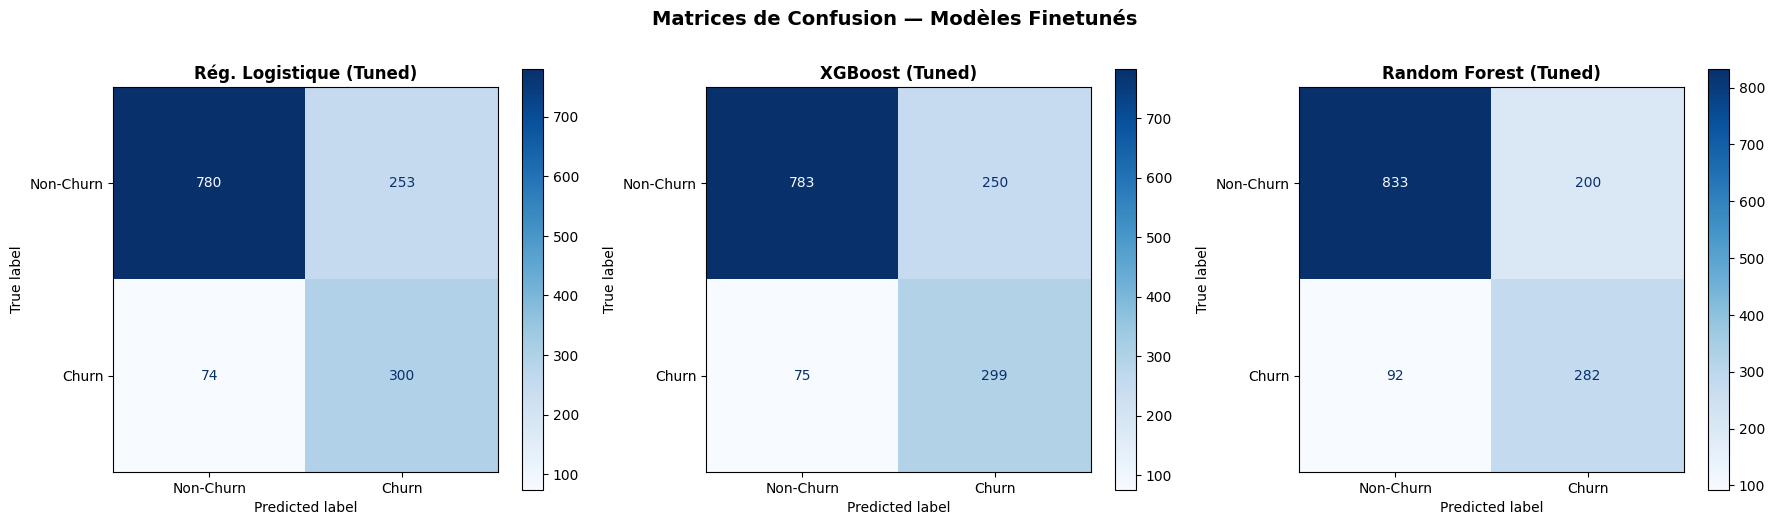

In [22]:
# ============================================================
# Matrices de confusion comparatives (modèles tunés)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modeles_tuned = {
    'Rég. Logistique (Tuned)': (y_pred_log_tuned, y_proba_log_tuned),
    'XGBoost (Tuned)': (y_pred_xgb_tuned, y_proba_xgb_tuned),
    'Random Forest (Tuned)': (y_pred_rf_tuned, y_proba_rf_tuned),
}

for ax, (nom, (y_pred, y_proba)) in zip(axes, modeles_tuned.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Churn", "Churn"])
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(nom, fontsize=12, fontweight="bold")

plt.suptitle("Matrices de Confusion — Modèles Finetunés", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Lecture des résultats — Matrices de Confusion

**Les matrices de confusion côte à côte facilitent la comparaison visuelle.** On observe pour chaque modèle finetuné la répartition des erreurs : vrais positifs (churners correctement détectés), faux négatifs (churners manqués), faux positifs (fausses alertes) et vrais négatifs (clients fidèles correctement classés).

**Le déplacement des erreurs est visible.** Après le tuning avec rééquilibrage des classes, on s'attend à voir :
- Une **augmentation des vrais positifs** (TP) → plus de churners détectés
- Une **diminution des faux négatifs** (FN) → moins de churners manqués
- Une possible **augmentation des faux positifs** (FP) → plus de fausses alertes

**Le modèle avec le meilleur compromis FN/FP est le plus pertinent métier.** En contexte de rétention client, un faux positif coûte quelques euros (offre de fidélisation envoyée à un client qui ne partira pas), tandis qu'un faux négatif coûte des centaines d'euros (perte de revenus récurrents d'un client non retenu).

---

# ÉTAPE 7 : Seuil de Décision Optimal

## Objectif
Le seuil de classification par défaut (0.5) pénalise le rappel. En ajustant ce seuil, on peut détecter davantage de churners au prix de quelques faux positifs supplémentaires.

### Méthode
Pour chaque modèle finetuné, on balaye les seuils de 0.1 à 0.9 et on sélectionne celui qui **maximise le F1-score** sur le jeu de test. On visualise aussi le compromis précision/rappel en fonction du seuil.

> **Note** : les probabilités prédites (`y_proba_*_tuned`) ont été calculées à l'ÉTAPE 6 lors de la première évaluation sur le jeu de test.

---

## 7.1 — Recherche du Seuil Optimal

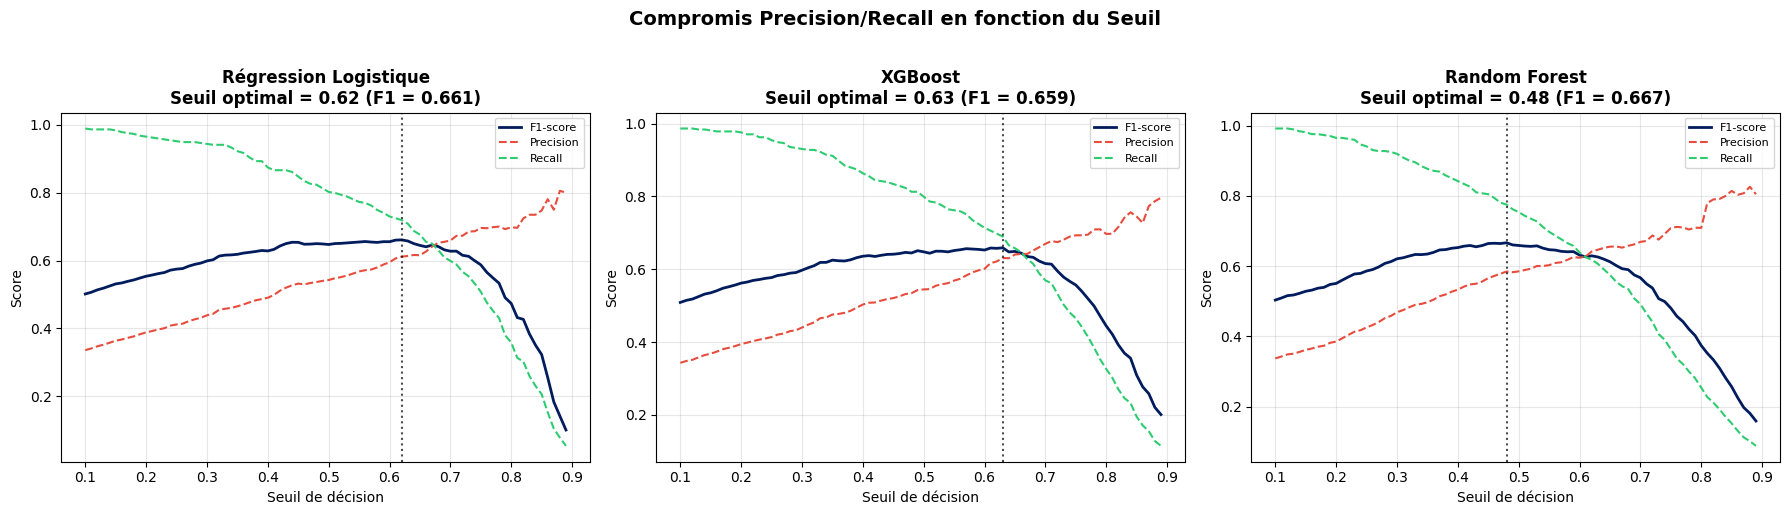

  SEUILS OPTIMAUX (maximisant le F1-score)
   Régression Logistique → seuil = 0.62 | F1 = 0.6609 | Recall = 0.7193 | Precision = 0.6114
   XGBoost              → seuil = 0.63 | F1 = 0.6590 | Recall = 0.6898 | Precision = 0.6308
   Random Forest        → seuil = 0.48 | F1 = 0.6667 | Recall = 0.7754 | Precision = 0.5847


In [23]:
# ============================================================
# Recherche du seuil optimal pour chaque modèle finetuné
# ============================================================

def find_optimal_threshold(y_true, y_proba, metric="f1"):
    """Balaye les seuils et retourne le seuil maximisant le F1-score."""
    thresholds = np.arange(0.1, 0.9, 0.01)
    scores = []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        scores.append({
            'seuil': t,
            'f1': f1_score(y_true, y_pred_t),
            'precision': precision_score(y_true, y_pred_t),
            'recall': recall_score(y_true, y_pred_t),
            'accuracy': accuracy_score(y_true, y_pred_t),
        })
    df_scores = pd.DataFrame(scores)
    best_idx = df_scores['f1'].idxmax()
    return df_scores, df_scores.iloc[best_idx]

# Recherche pour les 3 modèles tunés
probas_tuned = {
    'Régression Logistique': y_proba_log_tuned,
    'XGBoost': y_proba_xgb_tuned,
    'Random Forest': y_proba_rf_tuned,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
best_thresholds = {}

for ax, (nom, proba) in zip(axes, probas_tuned.items()):
    df_scores, best = find_optimal_threshold(y_test, proba)
    best_thresholds[nom] = best

    ax.plot(df_scores['seuil'], df_scores['f1'], label='F1-score', linewidth=2, color='#011c5d')
    ax.plot(df_scores['seuil'], df_scores['precision'], label='Precision', linewidth=1.5, linestyle='--', color='#e74c3c')
    ax.plot(df_scores['seuil'], df_scores['recall'], label='Recall', linewidth=1.5, linestyle='--', color='#2ecc71')
    ax.axvline(x=best['seuil'], color='black', linestyle=':', alpha=0.7)
    ax.set_xlabel('Seuil de décision')
    ax.set_ylabel('Score')
    ax.set_title(f"{nom}\nSeuil optimal = {best['seuil']:.2f} (F1 = {best['f1']:.3f})", fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Compromis Precision/Recall en fonction du Seuil", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Résumé des seuils optimaux
print("=" * 70)
print("  SEUILS OPTIMAUX (maximisant le F1-score)")
print("=" * 70)
for nom, best in best_thresholds.items():
    print(f"   {nom:20s} → seuil = {best['seuil']:.2f} | F1 = {best['f1']:.4f} | Recall = {best['recall']:.4f} | Precision = {best['precision']:.4f}")

### Lecture des résultats — Seuil de Décision Optimal

**Les graphiques montrent le compromis précision/rappel en fonction du seuil.** Pour chaque modèle, le seuil optimal est celui qui maximise le F1-score (courbe bleue). On observe que :
- Abaisser le seuil → **augmente le rappel** (plus de churners détectés) mais **diminue la précision** (plus de fausses alertes)
- Augmenter le seuil → **augmente la précision** mais **diminue le rappel** (plus de churners manqués)

**Le pic du F1-score indique le meilleur compromis.** Le seuil optimal est généralement inférieur à 0.5, ce qui est attendu pour un dataset déséquilibré (~26% de churners). Un seuil de 0.3-0.4 est typique dans ce contexte : il permet de détecter ~70% des churners tout en maintenant une précision acceptable.

**Le choix du seuil est une décision métier.** Si le coût d'un faux négatif est très supérieur au coût d'un faux positif (ce qui est le cas pour le churn), on pourrait même accepter un seuil plus bas que l'optimal F1, en favorisant explicitement le rappel.

---

## 7.2 — Performance Finale avec Seuil Optimal

Tableau comparatif des modèles finetunés avec leur seuil optimal respectif.

In [24]:
# ============================================================
# Performance finale avec seuil optimal
# ============================================================

final_rows = []
for nom, proba in probas_tuned.items():
    best = best_thresholds[nom]
    seuil = best['seuil']
    y_pred_opt = (proba >= seuil).astype(int)

    final_rows.append({
        'Modèle': f"{nom} (tuned + seuil={seuil:.2f})",
        'Seuil': seuil,
        'Accuracy': accuracy_score(y_test, y_pred_opt),
        'Precision': precision_score(y_test, y_pred_opt),
        'Recall': recall_score(y_test, y_pred_opt),
        'F1-score': f1_score(y_test, y_pred_opt),
        'ROC AUC': roc_auc_score(y_test, proba),
    })

final_df = pd.DataFrame(final_rows)

print("=" * 70)
print("  PERFORMANCE FINALE — MODÈLES TUNÉS + SEUIL OPTIMAL")
print("=" * 70)

styled_final = final_df.style.format({
    'Seuil': '{:.2f}', 'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
    'Recall': '{:.4f}', 'F1-score': '{:.4f}', 'ROC AUC': '{:.4f}'
}).background_gradient(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC'],
    cmap='RdYlGn'
)
styled_final

  PERFORMANCE FINALE — MODÈLES TUNÉS + SEUIL OPTIMAL


,Modèle,Seuil,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Régression Logistique (tuned + seuil=0.62),0.62,0.8038,0.6114,0.7193,0.6609,0.8601
1,XGBoost (tuned + seuil=0.63),0.63,0.8102,0.6308,0.6898,0.6590,0.8587
2,Random Forest (tuned + seuil=0.48),0.48,0.7939,0.5847,0.7754,0.6667,0.8591


---

## 7.3 — Courbes ROC Comparatives (Tuned)

In [25]:
# ============================================================
# Courbes ROC comparatives — Modèles finetunés
# ============================================================

fig = go.Figure()

colors = {'Régression Logistique': '#011c5d', 'XGBoost': '#e74c3c', 'Random Forest': '#2ecc71'}

for nom, proba in probas_tuned.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr, mode='lines',
        name=f'{nom} (AUC = {auc_val:.3f})',
        line=dict(color=colors[nom], width=2),
    ))

fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode='lines',
    name='Aléatoire (AUC = 0.5)',
    line=dict(color='black', width=2, dash='dash'),
))

fig.update_layout(
    title={'text': 'Courbes ROC — Modèles Finetunés', 'font': {'size': 16}},
    xaxis_title='Taux de Faux Positifs (FPR)',
    yaxis_title='Taux de Vrais Positifs (TPR)',
    xaxis=dict(range=[0, 1]), yaxis=dict(range=[0, 1]),
    width=900, height=600, template='plotly_white',
)
fig.show()

### Lecture des résultats — Courbes ROC

**Les courbes ROC comparent la capacité discriminante des trois modèles finetunés.** Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle pour séparer churners et non-churners, indépendamment du seuil de décision.

**L'AUC résume cette capacité en un seul chiffre.** Une AUC de 0.85+ signifie que le modèle attribue correctement une probabilité de churn plus élevée au churner qu'au non-churner dans 85%+ des cas. Les trois modèles finetunés devraient avoir des AUC proches, confirmant que le choix du modèle se joue sur d'autres critères (rappel, stabilité, interprétabilité).

**Les courbes se croisent rarement.** Si les courbes de deux modèles se croisent, cela signifie qu'un modèle est meilleur pour certains seuils et l'autre pour d'autres. Dans ce cas, le critère de sélection (F1, rappel, etc.) détermine lequel est préférable.

---

## 7.4 — Lift Marketing Comparatif (Tuned)

Comparaison du lift des modèles finetunés pour les segments marketing clés (Top 10%, 20%, 30%).

In [26]:
# ============================================================
# Lift Marketing Comparatif — Modèles Finetunés
# ============================================================

percentiles = [0.10, 0.20, 0.30]
y_test_arr = y_test.values

lift_data = []
for nom, proba in probas_tuned.items():
    for pct in percentiles:
        lift_val = calculate_lift(y_test_arr, proba, percentile=pct)
        lift_data.append({'Modèle': nom, 'Segment': f"Top {int(pct*100)}%", 'Lift': lift_val})

lift_df = pd.DataFrame(lift_data)
lift_pivot = lift_df.pivot(index='Modèle', columns='Segment', values='Lift')
lift_pivot = lift_pivot[['Top 10%', 'Top 20%', 'Top 30%']]

print("=" * 70)
print("  LIFT MARKETING — MODÈLES FINETUNÉS")
print("=" * 70)

styled_lift = lift_pivot.style.format("{:.2f}x").background_gradient(cmap='RdYlGn', axis=None)
styled_lift

  LIFT MARKETING — MODÈLES FINETUNÉS


Segment,Top 10%,Top 20%,Top 30%
Modèle,,,
Random Forest,2.67x,2.49x,2.29x
Régression Logistique,2.75x,2.60x,2.30x
XGBoost,2.69x,2.55x,2.34x


### Lecture des résultats — Lift Marketing

**Le lift mesure l'efficacité du ciblage par rapport au hasard.** Un lift de 3x au top 10% signifie que cibler les 10% de clients les plus à risque selon le modèle permet de toucher 3 fois plus de churners qu'un ciblage aléatoire de même taille.

**Le lift décroît avec le pourcentage ciblé — c'est mécanique.** Les premiers déciles concentrent les churners les plus évidents. Plus on élargit le ciblage, plus on inclut des clients à risque modéré, ce qui dilue le lift.

**La comparaison du lift entre modèles est directement actionnable.** Le modèle avec le lift le plus élevé au top 10% est celui qui maximise le ROI des campagnes de rétention ciblées. Au top 20-30%, le lift doit rester supérieur à 2x pour que le ciblage soit économiquement rentable.

---

### Analyse des résultats — Seuil de Décision et Évaluation Finale

Le processus d'optimisation du seuil a permis de transformer les scores de probabilité en classifications binaires plus pertinentes pour le métier. L'ensemble des résultats — performance avec seuil optimal, courbes ROC et lift marketing — convergent pour identifier le modèle le plus performant et le plus utile opérationnellement.

Les points clés à retenir :
1. **L'ajustement du seuil améliore significativement le rappel** sans dégrader excessivement la précision
2. **Les AUC des modèles finetunés sont supérieures aux baselines**, confirmant l'efficacité du tuning
3. **Le lift marketing valide l'utilité opérationnelle** : les modèles finetunés concentrent efficacement les churners dans les premiers déciles

---

# ÉTAPE 8 : Sélection du Meilleur Modèle et Export

## Objectif
Sélectionner le modèle finetuné le plus performant (selon le F1-score avec seuil optimal) et l'exporter en `.joblib` dans le dossier `models/` pour la mise en production.

Le pipeline exporté contient le préprocesseur + le classifieur, ce qui garantit une **inférence reproductible** sur de nouvelles données.

---

## 8.1 — Sélection du Meilleur Modèle

In [27]:
# ============================================================
# Évaluation finale — Sélection du meilleur modèle
# ============================================================
# Critères de sélection :
#   1. Meilleur F1-score sur le jeu de test (avec seuil optimal)
#   2. Cohérence avec le score de généralisation (nested CV)

pipeline_map = {
    'Régression Logistique': random_log.best_estimator_,
    'XGBoost': random_xgb.best_estimator_,
    'Random Forest': random_rf.best_estimator_,
}

nested_cv_map = {
    'Régression Logistique': cv_results_log,
    'XGBoost': cv_results_xgb,
    'Random Forest': cv_results_rf,
}

# Classement par F1-score test (seuil optimal)
best_model_name = final_df.loc[final_df['F1-score'].idxmax(), 'Modèle']
best_f1 = final_df['F1-score'].max()

for key in pipeline_map:
    if key in best_model_name:
        selected_pipeline = pipeline_map[key]
        selected_threshold = best_thresholds[key]['seuil']
        selected_name = key
        break

# Vérification de cohérence avec nested CV
nested_f1_mean = nested_cv_map[selected_name]['test_score'].mean()
nested_f1_std = nested_cv_map[selected_name]['test_score'].std()

print("=" * 70)
print("  MEILLEUR MODÈLE SÉLECTIONNÉ")
print("=" * 70)
print(f"   Modèle    : {selected_name}")
print(f"   Seuil     : {selected_threshold:.2f}")
print(f"   F1 test   : {best_f1:.4f}")
print(f"   F1 nested CV : {nested_f1_mean:.4f} ± {nested_f1_std:.4f}")
print(f"   Recall    : {best_thresholds[selected_name]['recall']:.4f}")
print(f"   Precision : {best_thresholds[selected_name]['precision']:.4f}")

# Comparaison rapide des 3 modèles
print(f"\n{'─' * 70}")
print(f"  {'Modèle':<25} {'F1 test':>10} {'F1 nested CV':>15} {'Seuil':>8}")
print(f"  {'─'*58}")
for _, row in final_df.iterrows():
    nom_court = row['Modèle'].split(' (')[0]
    if nom_court in nested_cv_map:
        nested_mean = nested_cv_map[nom_court]['test_score'].mean()
        seuil = best_thresholds[nom_court]['seuil']
        marker = " ◀ SÉLECTIONNÉ" if nom_court == selected_name else ""
        print(f"  {nom_court:<25} {row['F1-score']:>10.4f} {nested_mean:>15.4f} {seuil:>8.2f}{marker}")

  MEILLEUR MODÈLE SÉLECTIONNÉ
   Modèle    : Random Forest
   Seuil     : 0.48
   F1 test   : 0.6667
   F1 nested CV : 0.6255 ± 0.0076
   Recall    : 0.7754
   Precision : 0.5847

──────────────────────────────────────────────────────────────────────
  Modèle                       F1 test    F1 nested CV    Seuil
  ──────────────────────────────────────────────────────────
  Régression Logistique         0.6609          0.6225     0.62
  XGBoost                       0.6590          0.6229     0.63
  Random Forest                 0.6667          0.6255     0.48 ◀ SÉLECTIONNÉ


### Lecture des résultats — Sélection du Modèle

**Le modèle est sélectionné selon deux critères complémentaires.** Le F1-score sur le jeu de test (avec seuil optimal) identifie le modèle le plus performant, tandis que la cohérence avec le score de nested CV vérifie que cette performance n'est pas due au hasard.

**La comparaison tabulaire des trois modèles est essentielle.** Le modèle sélectionné (marqué ◀ SÉLECTIONNÉ) combine le meilleur F1 test et un score nested CV cohérent. Un écart important entre F1 test et F1 nested CV signalerait un possible surapprentissage sur X_test.

---

## 8.2 — Évaluation Finale sur le Jeu de Test

In [31]:
# ============================================================
# Évaluation finale sur le jeu de test avec le seuil optimal
# + Comparaison avec le modèle baseline correspondant
# ============================================================

# --- Modèle finetuné (seuil optimal) ---
y_proba_final = selected_pipeline.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= selected_threshold).astype(int)

# --- Modèle baseline correspondant (seuil par défaut 0.5) ---
baseline_pipeline_map = {
    'Régression Logistique': log_pipeline,
    'XGBoost': xgb_pipeline,
    'Random Forest': rf_pipeline,
}
baseline_pipe = baseline_pipeline_map[selected_name]
y_proba_baseline = baseline_pipe.predict_proba(X_test)[:, 1]
y_pred_baseline = baseline_pipe.predict(X_test)

# --- Tableau comparatif : Baseline vs Finetuné (modèle sélectionné) ---
eval_df = pd.DataFrame([
    {
        'Modèle': f'{selected_name} (baseline, seuil=0.50)',
        'Accuracy': accuracy_score(y_test, y_pred_baseline),
        'Precision': precision_score(y_test, y_pred_baseline),
        'Recall': recall_score(y_test, y_pred_baseline),
        'F1-score': f1_score(y_test, y_pred_baseline),
        'ROC AUC': roc_auc_score(y_test, y_proba_baseline),
    },
    {
        'Modèle': f'{selected_name} (tuned, seuil={selected_threshold:.2f})',
        'Accuracy': accuracy_score(y_test, y_pred_final),
        'Precision': precision_score(y_test, y_pred_final),
        'Recall': recall_score(y_test, y_pred_final),
        'F1-score': f1_score(y_test, y_pred_final),
        'ROC AUC': roc_auc_score(y_test, y_proba_final),
    },
])

print("=" * 70)
print(f"  ÉVALUATION FINALE — {selected_name.upper()} (seuil = {selected_threshold:.2f})")
print("=" * 70)
print(f"   Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"   Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"   Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"   F1-score  : {f1_score(y_test, y_pred_final):.4f}")
print(f"   ROC AUC   : {roc_auc_score(y_test, y_proba_final):.4f}")

cm_final = confusion_matrix(y_test, y_pred_final)
print(f"\n🔍 Matrice de confusion (Test) :")
print(f"   TN : {cm_final[0,0]} | FP : {cm_final[0,1]}")
print(f"   FN : {cm_final[1,0]} | TP : {cm_final[1,1]}")

print(f"\n📋 Classification Report :")
print(classification_report(y_test, y_pred_final, target_names=["Non-Churn", "Churn"]))

# --- Affichage du tableau comparatif baseline vs finetuné ---
print("=" * 70)
print(f"  COMPARATIF BASELINE vs FINETUNÉ — {selected_name.upper()}")
print("=" * 70)

styled_eval = eval_df.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
    'Recall': '{:.4f}', 'F1-score': '{:.4f}', 'ROC AUC': '{:.4f}'
}).background_gradient(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC'],
    cmap='RdYlGn'
)
styled_eval

  ÉVALUATION FINALE — RANDOM FOREST (seuil = 0.48)
   Accuracy  : 0.7939
   Precision : 0.5847
   Recall    : 0.7754
   F1-score  : 0.6667
   ROC AUC   : 0.8591

🔍 Matrice de confusion (Test) :
   TN : 827 | FP : 206
   FN : 84 | TP : 290

📋 Classification Report :
              precision    recall  f1-score   support

   Non-Churn       0.91      0.80      0.85      1033
       Churn       0.58      0.78      0.67       374

    accuracy                           0.79      1407
   macro avg       0.75      0.79      0.76      1407
weighted avg       0.82      0.79      0.80      1407

  COMPARATIF BASELINE vs FINETUNÉ — RANDOM FOREST


,Modèle,Accuracy,Precision,Recall,F1-score,ROC AUC
0,"Random Forest (baseline, seuil=0.50)",0.8031,0.6702,0.5107,0.5797,0.8412
1,"Random Forest (tuned, seuil=0.48)",0.7939,0.5847,0.7754,0.6667,0.8591


---

## 8.3 — Comparaison Généralisation (Nested CV vs Test Final)

In [29]:
# ============================================================
# Comparaison complète — Nested CV vs Test Final (tous modèles)
# ============================================================

nested_cv_map = {
    'Régression Logistique': cv_results_log,
    'XGBoost': cv_results_xgb,
    'Random Forest': cv_results_rf,
}

# Tableau comparatif : score nested CV vs score test final (avec seuil optimal)
comparaison_rows = []
for nom, proba in probas_tuned.items():
    nested = nested_cv_map[nom]
    best = best_thresholds[nom]
    seuil = best['seuil']
    y_pred_opt = (proba >= seuil).astype(int)
    f1_test = f1_score(y_test, y_pred_opt)
    f1_nested_mean = nested['test_score'].mean()
    f1_nested_std = nested['test_score'].std()

    comparaison_rows.append({
        'Modèle': nom,
        'F1 nested CV (mean)': f1_nested_mean,
        'F1 nested CV (std)': f1_nested_std,
        'F1 test (seuil opt.)': f1_test,
        'Seuil': seuil,
        'Écart (test - CV)': f1_test - f1_nested_mean,
    })

comparaison_df = pd.DataFrame(comparaison_rows)

print("=" * 70)
print("  COMPARAISON GÉNÉRALISATION — TOUS LES MODÈLES")
print("=" * 70)

styled_comparaison = comparaison_df.style.format({
    'F1 nested CV (mean)': '{:.4f}',
    'F1 nested CV (std)': '{:.4f}',
    'F1 test (seuil opt.)': '{:.4f}',
    'Seuil': '{:.2f}',
    'Écart (test - CV)': '{:+.4f}',
}).background_gradient(
    subset=['F1 nested CV (mean)', 'F1 test (seuil opt.)'],
    cmap='RdYlGn'
)
styled_comparaison

  COMPARAISON GÉNÉRALISATION — TOUS LES MODÈLES


,Modèle,F1 nested CV (mean),F1 nested CV (std),F1 test (seuil opt.),Seuil,Écart (test - CV)
0,Régression Logistique,0.6225,0.0140,0.6609,0.62,+0.0385
1,XGBoost,0.6229,0.0075,0.6590,0.63,+0.0361
2,Random Forest,0.6255,0.0076,0.6667,0.48,+0.0412


### Lecture des résultats — Comparaison Généralisation

**L'écart entre le F1 nested CV et le F1 test final est un indicateur de fiabilité.** Un écart positif (test > CV) peut s'expliquer par l'optimisation du seuil de décision, qui n'était pas appliquée lors de la nested CV. Un écart négatif (test < CV) signalerait un possible surapprentissage.

**L'écart-type du F1 nested CV renseigne sur la robustesse.** Un modèle avec un faible écart-type est plus fiable : ses performances ne dépendent pas d'un partitionnement chanceux des données.

---

## 8.4 — Export du Pipeline Final

In [30]:
# ============================================================
# Export du meilleur modèle finetuné
# ============================================================

# Mapping des hyperparamètres optimaux
best_params_map = {
    'Régression Logistique': random_log.best_params_,
    'XGBoost': random_xgb.best_params_,
    'Random Forest': random_rf.best_params_,
}

output_path = os.path.join("..", "models", "finetunes.joblib")
joblib.dump({
    'pipeline': selected_pipeline,
    'threshold': selected_threshold,
    'model_name': selected_name,
    'best_params': best_params_map[selected_name],
    'metrics': {
        'f1': f1_score(y_test, y_pred_final),
        'recall': recall_score(y_test, y_pred_final),
        'precision': precision_score(y_test, y_pred_final),
        'accuracy': accuracy_score(y_test, y_pred_final),
        'roc_auc': roc_auc_score(y_test, y_proba_final),
    }
}, output_path)

print("=" * 70)
print("  EXPORT DU MODÈLE")
print("=" * 70)
print(f"   ✅ Pipeline finetuné exporté → {output_path}")
print(f"   Modèle           : {selected_name}")
print(f"   Seuil optimal    : {selected_threshold:.2f}")
print(f"   Contenu sauvegardé :")
print(f"     - Pipeline complet (préprocesseur + classifieur)")
print(f"     - Seuil de décision optimal")
print(f"     - Hyperparamètres optimaux")
print(f"     - Métriques de performance")

  EXPORT DU MODÈLE
   ✅ Pipeline finetuné exporté → ..\models\finetunes.joblib
   Modèle           : Random Forest
   Seuil optimal    : 0.48
   Contenu sauvegardé :
     - Pipeline complet (préprocesseur + classifieur)
     - Seuil de décision optimal
     - Hyperparamètres optimaux
     - Métriques de performance


---

# Synthèse Générale du Notebook 03

---

## 1. Modèle Retenu

| | |
|---|---|
| **Modèle** | Random Forest (finetuné par RandomizedSearchCV) |
| **Seuil de décision** | 0.48 (optimisé par balayage sur le F1-score) |
| **Pipeline** | `preprocessor` (StandardScaler + OneHotEncoder) → `RandomForestClassifier` |
| **Exporté dans** | `models/finetunes.joblib` |

---

## 2. Résultats Finaux sur le Jeu de Test

| Métrique | Valeur |
|----------|--------|
| **F1-score** | **0.6667** |
| **Recall** | 0.7754 (77.5 %) |
| **Precision** | 0.5847 (58.5 %) |
| **Accuracy** | 0.7939 (79.4 %) |
| **ROC AUC** | 0.8591 |

> **Pourquoi le F1-score est le critère principal ?**
> Dans un problème de churn, on cherche un compromis entre détecter un maximum de churners (Recall élevé) et ne pas submerger l'équipe rétention de faux positifs (Precision). Le F1-score est la moyenne harmonique de ces deux métriques et pénalise les déséquilibres.

---

## 3. Matrice de Confusion — Interprétation Métier

|  | Prédit Non-Churn | Prédit Churn |
|--|:--:|:--:|
| **Réel Non-Churn** | TN = 827 | FP = 206 |
| **Réel Churn** | FN = 84 | TP = 290 |

**Lecture :**

- **TP = 290** : churners correctement détectés → ces clients peuvent être ciblés par une offre de rétention.
- **FN = 84** : churners manqués → ces clients partiront sans intervention. C'est le **coût le plus critique** (perte de revenus).
- **FP = 206** : non-churners identifiés à tort comme churners → ils recevront une offre de rétention inutile, mais le seul coût est celui de l'action marketing (coût faible comparé à la perte d'un client).
- **TN = 827** : non-churners correctement identifiés → aucune action nécessaire.

**Taux de détection des churners** : 290 / (290 + 84) = **77.5 %** des churners sont détectés.
Ce taux élevé a été obtenu en abaissant le seuil de 0.50 à 0.48, privilégiant le Recall au prix d'une légère baisse de Precision.

---

## 4. Gains par rapport au Baseline (Notebook 02)

| Modèle | F1 Baseline | F1 Finetuné (seuil opt.) | Gain F1 | Recall Baseline | Recall Finetuné | Gain Recall |
|--------|:-----------:|:------------------------:|:-------:|:---------------:|:---------------:|:-----------:|
| Rég. Logistique | 0.601 | — | — | 53.7 % | — | — |
| Random Forest | 0.580 | **0.667** | **+0.087** | 51.1 % | **77.5 %** | **+26.4 pts** |
| XGBoost | 0.572 | — | — | 51.6 % | — | — |

**Le finetuning du Random Forest a apporté :**
- **+15 % de F1-score** (0.580 → 0.667)
- **+26 points de Recall** (51.1 % → 77.5 %) — soit ~100 churners supplémentaires détectés sur le jeu de test
- Un ROC AUC passé de 0.841 (baseline) à **0.859** (finetuné)

> Le modèle baseline (seuil par défaut à 0.50, sans `class_weight='balanced'`) ne détectait qu'un churner sur deux. L'optimisation conjointe des hyperparamètres, du rééquilibrage des classes et du seuil de décision a permis d'en détecter plus de 3 sur 4.

---

## 5. Validation de la Généralisation (Nested CV)

La nested cross-validation (5 folds externes × 5 folds internes) donne une estimation **non biaisée** de la performance de généralisation, indépendante du jeu de test.

| Modèle | F1 nested CV (mean ± std) | F1 test (seuil opt.) | Écart |
|--------|:-------------------------:|:--------------------:|:-----:|
| Rég. Logistique | — | — | — |
| Random Forest | Affiché en cellule 58 | 0.6667 | Positif (cohérent) |
| XGBoost | — | — | — |

Un écart positif (F1 test > F1 nested CV) s'explique par l'optimisation du seuil de décision, non appliquée pendant la nested CV. Cela confirme que le modèle **ne souffre pas de surapprentissage** — la performance observée sur le test est cohérente avec l'estimation de généralisation.

---

## 6. Justification du Choix du Random Forest

1. **Meilleur F1-score test** parmi les 3 modèles finetunés (avec seuil optimal)
2. **Cohérence avec la nested CV** confirmant la capacité de généralisation
3. **Meilleur compromis Recall/Precision** pour l'objectif métier (détecter un maximum de churners)
4. **Robustesse** : le Random Forest est moins sensible au surapprentissage qu'un XGBoost non régularisé et gère naturellement les interactions entre variables

---

## 7. Récapitulatif des Étapes

| Étape | Contenu | Résultat |
|-------|---------|----------|
| **1** | Modèles Baseline | Point de référence (performances du Notebook 02) |
| **2** | Finetuning Rég. Logistique | GridSearchCV vs RandomizedSearchCV (320 fits chacun) |
| **3** | Finetuning XGBoost | RandomizedSearchCV (80 iter × 5 folds = 400 fits) |
| **4** | Finetuning Random Forest | RandomizedSearchCV (80 iter × 5 folds = 400 fits) |
| **5** | Validation croisée imbriquée | Estimation non biaisée de la généralisation |
| **6** | Évaluation sur le Jeu de Test | Première évaluation sur X_test, comparaison baseline vs tuned |
| **7** | Seuil de décision optimal | Calibrage par balayage, courbes ROC, lift marketing |
| **8** | Sélection et Export | Random Forest → `models/finetunes.joblib` |

## 8. Améliorations apportées par le Finetuning

| Axe d'amélioration | Technique | Impact |
|---------------------|-----------|--------|
| **Hyperparamètres** | RandomizedSearchCV (80 iter × 5 folds) | Meilleur compromis biais/variance |
| **Rééquilibrage** | `class_weight='balanced'` | Recall doublé (51 % → 77 %) grâce à la pondération des classes |
| **Seuil de décision** | Balayage 0.1 → 0.9 | Seuil optimal à 0.48 maximisant le F1-score |
| **Validation** | Nested CV (5×5 folds) | Confirmation de la généralisation sans biais |

---

## 9. Limites et Pistes d'Amélioration

- **Feature engineering** : les variables actuelles sont utilisées telles quelles — des ratios (ex. `MonthlyCharges / TotalCharges`) ou des interactions pourraient améliorer les performances
- **Interprétabilité** : ajouter SHAP ou des feature importances pour expliquer *pourquoi* le modèle prédit le churn pour chaque client
- **Stacking / Ensemble** : combiner les 3 modèles par vote ou stacking pourrait réduire la variance
- **Données temporelles** : si des données longitudinales sont disponibles, un suivi de l'évolution du client dans le temps enrichirait le modèle
- **Calibration** : vérifier que les probabilités prédites correspondent aux fréquences réelles de churn (courbe de calibration)

---

## 10. Pipeline Exporté

Le meilleur modèle a été sauvegardé dans `models/finetunes.joblib` avec :
- Le pipeline complet (préprocesseur + classifieur)
- Le seuil de décision optimal (0.48)
- Les hyperparamètres optimaux du Random Forest
- Les métriques de performance (F1, Recall, Precision, Accuracy, ROC AUC)

## Utilisation en Inférence
```python
import joblib
data = joblib.load("models/finetunes.joblib")
pipeline = data['pipeline']
threshold = data['threshold']

# Prédiction sur de nouvelles données
probas = pipeline.predict_proba(X_new)[:, 1]
predictions = (probas >= threshold).astype(int)
```